In [3]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [ ]:
#Linear Regression
# 1. Load the dataset
housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target

# Display some basic info
print("Features (X) head:")
print(X.head())
print("\nTarget (y) head:")
print(y.head())
print(f"\nDataset shape: {X.shape}")

Features (X) head:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Target (y) head:
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

Dataset shape: (20640, 8)


In [5]:
# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

# 3. Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Make predictions on the test set
y_pred = model.predict(X_test)

# 5. Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n--- Model Evaluation ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r2:.2f}")


Training set size: 16512 samples
Test set size: 4128 samples

--- Model Evaluation ---
Root Mean Squared Error (RMSE): 0.75
R-squared (R²): 0.58


In [6]:
# Display model coefficients and intercept
print(f"\nModel Intercept: {model.intercept_:.2f}")
print(f"Model Coefficients:")
for i, feature in enumerate(X.columns):
    print(f"  {feature}: {model.coef_[i]:.2f}")


Model Intercept: -37.02
Model Coefficients:
  MedInc: 0.45
  HouseAge: 0.01
  AveRooms: -0.12
  AveBedrms: 0.78
  Population: -0.00
  AveOccup: -0.00
  Latitude: -0.42
  Longitude: -0.43


In [ ]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Sample data for demonstration
# X: features (e.g., test score, hours studied)
# y: target (0 for fail, 1 for pass)
X = np.array([[1, 2], [2, 3], [3, 4], [4, 5], [5, 6],
              [1, 1], [2, 2], [3, 3], [0, 1], [1, 0]])
y = np.array([1, 1, 1, 1, 1, 0, 0, 0, 0, 0])

# Split data (optional for simple demo, but good practice)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train the Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test) # Probabilities

print("Predicted classes:", y_pred)
print("Predicted probabilities (first 5 samples):\n", y_prob[:5])
print("Accuracy:", accuracy_score(y_test, y_pred))


Predicted classes: [0 1 0]
Predicted probabilities (first 5 samples):
 [[0.72021813 0.27978187]
 [0.39645551 0.60354449]
 [0.76440602 0.23559398]]
Accuracy: 1.0


In [ ]:
#KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# Sample data
X = np.array([[1, 2], [2, 3], [3, 4], [4, 5], [5, 6],
              [1, 1], [2, 2], [3, 3], [0, 1], [1, 0]])
y = np.array([1, 1, 1, 1, 1, 0, 0, 0, 0, 0])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Feature Scaling (important for KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train KNN model
# For demonstration, let's use K=3
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)

# Make predictions
y_pred = knn.predict(X_test_scaled)
print("Predicted classes:", y_pred)
print("Accuracy:", knn.score(X_test_scaled, y_test))


Predicted classes: [0 0 0]
Accuracy: 0.6666666666666666


In [9]:
#Decision Trees
from sklearn.tree import DecisionTreeClassifier

# Sample data
X = np.array([[1, 2], [2, 3], [3, 4], [4, 5], [5, 6],
              [1, 1], [2, 2], [3, 3], [0, 1], [1, 0]])
y = np.array([1, 1, 1, 1, 1, 0, 0, 0, 0, 0])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train the Decision Tree model
# max_depth controls the depth of the tree to prevent overfitting
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions
y_pred = dt_model.predict(X_test)

print("Predicted classes:", y_pred)
print("Accuracy:", dt_model.score(X_test, y_test))

Predicted classes: [0 0 0]
Accuracy: 0.6666666666666666


In [10]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

# Sample data
X = np.array([[1, 2], [2, 3], [3, 4], [4, 5], [5, 6],
              [1, 1], [2, 2], [3, 3], [0, 1], [1, 0]])
y = np.array([1, 1, 1, 1, 1, 0, 0, 0, 0, 0])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train the Random Forest model
# n_estimators: number of trees in the forest
# max_depth: controls the maximum depth of each tree
rf_model = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

print("Predicted classes:", y_pred)
print("Accuracy:", rf_model.score(X_test, y_test))

# Bonus: Feature Importance
# Random Forests can also provide insights into which features are most important
# for making predictions.
print("Feature Importances:", rf_model.feature_importances_)

Predicted classes: [0 0 0]
Accuracy: 0.6666666666666666
Feature Importances: [0.38899309 0.61100691]


In [11]:
#Heart-Disease Dataset plus all the models

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# --- 1. Data Loading ---
# For demonstration purposes, we will create a synthetic heart disease dataset.
# In a real-world scenario, you would load your dataset using pandas:
# df = pd.read_csv('heart_disease_data.csv')

# Create a synthetic dataset
np.random.seed(42)
num_samples = 500
data = {
    'age': np.random.randint(29, 77, num_samples),
    'sex': np.random.randint(0, 2, num_samples), # 0=female, 1=male
    'chest_pain_type': np.random.randint(0, 4, num_samples), # 0-3
    'resting_bp': np.random.randint(100, 180, num_samples),
    'cholesterol': np.random.randint(120, 400, num_samples),
    'fasting_blood_sugar': np.random.randint(0, 2, num_samples), # 0 or 1
    'resting_ecg': np.random.randint(0, 3, num_samples), # 0-2
    'max_heart_rate': np.random.randint(90, 200, num_samples),
    'exercise_induced_angina': np.random.randint(0, 2, num_samples), # 0 or 1
    'oldpeak': np.round(np.random.uniform(0.0, 6.0, num_samples), 1),
    'slope': np.random.randint(0, 3, num_samples), # 0-2
    'num_major_vessels': np.random.randint(0, 4, num_samples), # 0-3
    'thallium_scan': np.random.randint(0, 4, num_samples), # 0-3
    'target': np.random.randint(0, 2, num_samples) # 0=no disease, 1=disease
}
df = pd.DataFrame(data)

print("Dataset head:")
print(df.head())
print("\nDataset info:")
df.info()

Dataset head:
   age  sex  chest_pain_type  resting_bp  cholesterol  fasting_blood_sugar  \
0   67    1                0         161          392                    0   
1   57    1                1         131          355                    0   
2   43    1                0         129          347                    1   
3   71    1                0         128          128                    1   
4   36    0                0         148          285                    0   

   resting_ecg  max_heart_rate  exercise_induced_angina  oldpeak  slope  \
0            0             179                        1      0.9      0   
1            0             192                        1      2.6      1   
2            0             181                        1      5.4      1   
3            0             158                        1      5.1      0   
4            0              97                        1      2.4      2   

   num_major_vessels  thallium_scan  target  
0                  3

In [13]:
# Separate features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

# --- 2. Train-Test Split ---
# Split the dataset into training and testing sets
# test_size=0.2 means 20% of the data will be used for testing
# random_state ensures reproducibility of the split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")


Training set size: 400 samples
Testing set size: 100 samples


In [14]:
# --- 3. Feature Scaling ---
# Initialize the StandardScaler to standardize numerical features
# Scaling is crucial for models like Logistic Regression and KNN
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
# We fit only on training data to prevent data leakage from the test set
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for easier inspection (optional)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("\nScaled data head (first 5 rows of X_train_scaled):")
print(X_train_scaled.head())


Scaled data head (first 5 rows of X_train_scaled):
          age       sex  chest_pain_type  resting_bp  cholesterol  \
249  1.190644 -0.946433        -1.322713    0.427960    -0.664871   
433  1.118319 -0.946433        -0.402565    0.832119    -1.200329   
19   1.407618 -0.946433        -0.402565   -1.727556    -0.453178   
322  1.552267 -0.946433        -0.402565    1.775157     0.318878   
332  0.395073 -0.946433        -0.402565    0.383053     0.144543   

     fasting_blood_sugar  resting_ecg  max_heart_rate  \
249            -1.040833     1.249886       -0.006012   
433             0.960769     0.036404       -0.733812   
19             -1.040833     0.036404        0.436996   
322             0.960769    -1.177077        1.228082   
332            -1.040833     1.249886        0.690144   

     exercise_induced_angina   oldpeak     slope  num_major_vessels  \
249                 1.020204 -1.722084  1.140148           0.421712   
433                -0.980196  1.574918 -0.066358

In [15]:
# --- 4. Training All Classification Models ---

# Dictionary to store trained models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Train each model
print("\nTraining models...")
for name, model in models.items():
    if name in ["Logistic Regression", "K-Nearest Neighbors"]:
        # These models benefit from scaled data
        model.fit(X_train_scaled, y_train)
    else:
        # Tree-based models are generally less sensitive to scaling
        model.fit(X_train, y_train)
    print(f"- {name} trained.")


Training models...
- Logistic Regression trained.
- K-Nearest Neighbors trained.
- Decision Tree trained.
- Random Forest trained.



Evaluating models:

--- Logistic Regression ---
Accuracy: 0.4100
Precision: 0.3696
Recall: 0.3617
F1-Score: 0.3656
Confusion Matrix:
 [[24 29]
 [30 17]]


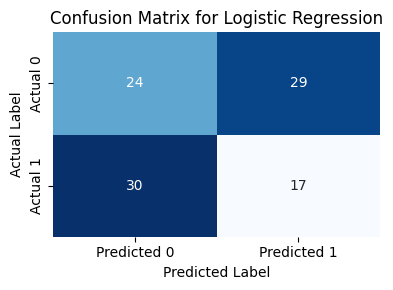


--- K-Nearest Neighbors ---
Accuracy: 0.4600
Precision: 0.4364
Recall: 0.5106
F1-Score: 0.4706
Confusion Matrix:
 [[22 31]
 [23 24]]


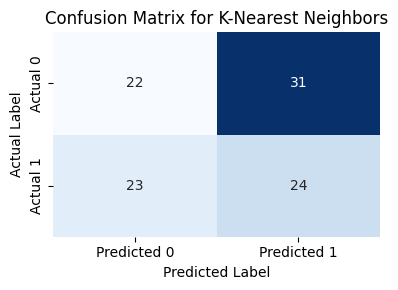


--- Decision Tree ---
Accuracy: 0.4900
Precision: 0.4444
Recall: 0.3404
F1-Score: 0.3855
Confusion Matrix:
 [[33 20]
 [31 16]]


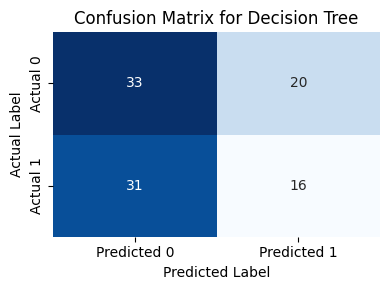


--- Random Forest ---
Accuracy: 0.4700
Precision: 0.4211
Recall: 0.3404
F1-Score: 0.3765
Confusion Matrix:
 [[31 22]
 [31 16]]


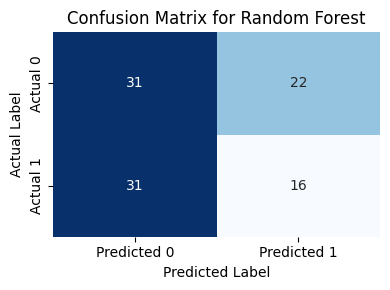


--- Model Comparison Summary ---
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
K-Nearest Neighbors      0.46     0.4364  0.5106    0.4706
Decision Tree            0.49     0.4444  0.3404    0.3855
Random Forest            0.47     0.4211  0.3404    0.3765
Logistic Regression      0.41     0.3696  0.3617    0.3656


In [16]:
# --- 5. Making Predictions and 6. Evaluating Models ---

print("\nEvaluating models:")
results = {}

for name, model in models.items():
    print(f"\n--- {name} ---")
    if name in ["Logistic Regression", "K-Nearest Neighbors"]:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0) # zero_division=0 handles cases where there are no positive predictions
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Confusion Matrix": cm
    }

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("Confusion Matrix:\n", cm)

    # Optional: Visualize Confusion Matrix
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title(f'Confusion Matrix for {name}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

# --- Summary of Results ---
print("\n--- Model Comparison Summary ---")
summary_df = pd.DataFrame({
    'Model': results.keys(),
    'Accuracy': [res['Accuracy'] for res in results.values()],
    'Precision': [res['Precision'] for res in results.values()],
    'Recall': [res['Recall'] for res in results.values()],
    'F1-Score': [res['F1-Score'] for res in results.values()]
})
summary_df = summary_df.set_index('Model').sort_values(by='F1-Score', ascending=False)
print(summary_df.round(4))